In [1]:
import pandas as pd
from sklearn.neighbors import BallTree
import numpy as np
import requests
import time
import unicodedata

In [2]:
final_df = pd.read_csv("../data/final_df.csv")
sch_data = pd.read_csv("../outputs/Good_School_index.csv")

EARTH_RADIUS_KM = 6371

# Ensure year is int
final_df["year"] = final_df["year"].astype(int)
sch_data["year"] = sch_data["year"].astype(int)

# Convert HDB coords to radians
final_df["_lat_rad"] = np.radians(final_df["lat"])
final_df["_lon_rad"] = np.radians(final_df["lon"])

In [3]:
# lat lon for sch

SEARCH_URL = "https://www.onemap.gov.sg/api/common/elastic/search"

def geocode_onemap(search_val, session=None, auth_token=None, retries=3, sleep=0.3):
    s = session or requests.Session()
    headers = {"Authorization": auth_token} if auth_token else {}
    params = {
        "searchVal": search_val,
        "returnGeom": "Y",
        "getAddrDetails": "Y",
        "pageNum": 1
    }

    for i in range(retries):
        try:
            r = s.get(SEARCH_URL, params=params, headers=headers, timeout=15)
            r.raise_for_status()
            j = r.json()
            if int(j.get("found", 0)) > 0:
                best = j["results"][0]
                return float(best["LATITUDE"]), float(best["LONGITUDE"])
            return None, None
        except Exception:
            if i == retries - 1:
                return None, None
            time.sleep((i + 1) * sleep)



In [4]:
sess = requests.Session()

def normalize_name(s):
    if pd.isna(s):
        return s
    s = str(s).strip()
    s = unicodedata.normalize("NFKC", s)
    s = s.replace("’", "'").replace("‘", "'")
    return s

sch_data["search_school"] = sch_data["school"].map(normalize_name)

school_overrides = {
    "CHIJ (Toa Payoh)": "CHIJ Primary (Toa Payoh)",
    "St. Andrew's Junior": "St. Andrew's Junior School",
    "St. Anthony's": "St. Anthony's Primary School",
    "St. Anthony's Canossian": "St. Anthony's Canossian Primary School",
    "St. Gabriel's": "St. Gabriel's Primary School",
    "St. Hilda's": "St. Hilda's Primary School",
    "St. Joseph's Institution Junior": "St. Joseph's Institution Junior",
    "St. Margaret's": "St. Margaret's Primary School",
    "St. Stephen's": "St. Stephen's School",
    "CHIJ (Katong)": "CHIJ Katong Primary",
    "CHIJ Our Lady of Good Counsel": "CHIJ Our Lady of Good Counsel",
    "CHIJ Our Lady Queen of Peace": "CHIJ Our Lady Queen of Peace",
    "CHIJ (Kellock)": "CHIJ Kellock",
}

def geocode_school(name, session=None):
    # manual override first for known failures
    if name in school_overrides:
        queries = [school_overrides[name]]
    else:
        # generic rule for all others
        queries = [
            f"{name} Primary School",
            f"{name} School"
        ]
    
    for q in queries:
        lat, lon = geocode_onemap(q, session=session)
        if lat is not None and lon is not None:
            return lat, lon, q
    
    return None, None, None


sch_unique = sch_data["search_school"].dropna().unique()

sch_map = {}
sch_query_used = {}

for s in sch_unique:
    lat, lon, q_used = geocode_school(s, session=sess)
    sch_map[s] = (lat, lon)
    sch_query_used[s] = q_used

sch_data["lat"] = sch_data["search_school"].map(lambda x: sch_map.get(x, (None, None))[0])
sch_data["lon"] = sch_data["search_school"].map(lambda x: sch_map.get(x, (None, None))[1])
sch_data["query_used"] = sch_data["search_school"].map(sch_query_used)

In [5]:
print(sch_data.head())

   Unnamed: 0         school  year       GSI  good_school_75  good_school_80  \
0           0      Admiralty  2013  0.491796               0               0   
1           1  Ahmad Ibrahim  2013 -0.519466               0               0   
2           2        Ai Tong  2013  1.233564               1               1   
3           3      Alexandra  2013  0.430765               0               0   
4           4   Anchor Green  2013 -0.027182               0               0   

   good_school_85  good_school_90  search_school       lat         lon  \
0               0               0      Admiralty  1.442635  103.800040   
1               0               0  Ahmad Ibrahim  1.433153  103.832942   
2               1               1        Ai Tong  1.360583  103.833020   
3               0               0      Alexandra  1.291334  103.824425   
4               0               0   Anchor Green  1.390370  103.887165   

                     query_used  
0      Admiralty Primary School  
1  Ahm

In [6]:

# --------------------------------------------------
# Function: distance + nearest school name by year
# --------------------------------------------------
def nearest_school_by_year(hdb_df, sch_df, flag_col):
    n = len(hdb_df)
    
    dist_out = np.full(n, np.nan)
    name_out = np.array([None] * n, dtype=object)

    common_years = sorted(set(hdb_df["year"]) & set(sch_df["year"]))

    for yr in common_years:
        hdb_mask = hdb_df["year"] == yr
        sch_mask = (sch_df["year"] == yr) & (sch_df[flag_col] == 1)

        sch_subset = sch_df.loc[sch_mask, ["lat", "lon", "school"]].dropna()

        if sch_subset.empty:
            continue

        # Build BallTree
        school_coords = np.radians(sch_subset[["lat", "lon"]].values)
        tree = BallTree(school_coords, metric="haversine")

        # HDB subset
        hdb_idx = hdb_df.index[hdb_mask]
        hdb_coords = hdb_df.loc[hdb_idx, ["_lat_rad", "_lon_rad"]].values

        dist, ind = tree.query(hdb_coords, k=1)

        # Store distance
        dist_vals = dist.flatten() * EARTH_RADIUS_KM
        dist_out[hdb_df.index.get_indexer(hdb_idx)] = dist_vals

        # Store school names
        nearest_names = sch_subset.iloc[ind.flatten()]["school"].values
        name_out[hdb_df.index.get_indexer(hdb_idx)] = nearest_names

    return dist_out, name_out


# --------------------------------------------------
# Create variables
# --------------------------------------------------
d75, n75 = nearest_school_by_year(final_df, sch_data, "good_school_75")
d80, n80 = nearest_school_by_year(final_df, sch_data, "good_school_80")
d85, n85 = nearest_school_by_year(final_df, sch_data, "good_school_85")
d90, n90 = nearest_school_by_year(final_df, sch_data, "good_school_90")

final_df["dist_nearest_goodschool_75"] = d75
final_df["sch_name_75"] = n75

final_df["dist_nearest_goodschool_80"] = d80
final_df["sch_name_80"] = n80

final_df["dist_nearest_goodschool_85"] = d85
final_df["sch_name_85"] = n85

final_df["dist_nearest_goodschool_90"] = d90
final_df["sch_name_90"] = n90


# Cleanup
final_df.drop(columns=["_lat_rad", "_lon_rad"], inplace=True)

In [7]:
print(final_df.head())


        month        town  flat_type block       street_name  floor_area_sqm  \
0  2013-01-01  ANG MO KIO          2   510  ANG MO KIO AVE 8            44.0   
1  2013-01-01  ANG MO KIO          2   314  ANG MO KIO AVE 3            44.0   
2  2013-01-01  ANG MO KIO          2   323  ANG MO KIO AVE 3            44.0   
3  2013-01-01  ANG MO KIO          3   170  ANG MO KIO AVE 4            61.0   
4  2013-01-01  ANG MO KIO          3   174  ANG MO KIO AVE 4            60.0   

  flat_model  lease_commence_date  resale_price  year  ...  d_0_1km_good90  \
0   Improved                 1980      253000.0  2013  ...               0   
1   Improved                 1978      270000.0  2013  ...               0   
2   Improved                 1977      283000.0  2013  ...               0   
3   Improved                 1986      305000.0  2013  ...               1   
4   Improved                 1986      320000.0  2013  ...               1   

   d_1_2km_good90 dist_nearest_goodschool_75      

In [8]:
final_df.to_csv("../data/hdb_nearest_sch.csv", index=False)

## Base RDD

rdrobust available: False
Loaded: ..\data\hdb_nearest_sch.csv
Shape: (291419, 58)
Missingness in key columns:
log_real_price_psf            0.0
dist_nearest_goodschool_75    0.0
dist_nearest_goodschool_80    0.0
dist_nearest_goodschool_85    0.0
dist_nearest_goodschool_90    0.0
dtype: float64
Adjusted formula extras: floor_area_sqm + remaining_lease_years + dist_to_nearest_mrt_km + dist_to_nearest_mall_km + dist_to_nearest_hawker_km + dist_to_nearest_busstop_km + countall_0_1km + countall_1_2km + mature_estate + C(year) + C(town)
Main RDD results:


,spec,threshold,cutoff_km,bandwidth_km,coef,se,p_value,ci_lo,ci_hi,pct_effect,n,n_left,n_right
1,main_adjusted,75,1.0,0.5,0.002282,0.001236,6.480214e-02,-0.000140,0.004704,0.228455,156398,96435,59963
0,main_minimal,75,1.0,0.5,-0.001177,0.002331,6.137629e-01,-0.005746,0.003393,-0.117604,156398,96435,59963
3,main_adjusted,75,2.0,0.5,-0.002694,0.002266,2.346310e-01,-0.007136,0.001748,-0.268999,56378,38404,17974
2,main_minimal,75,2.0,0.5,0.064297,0.005084,1.172608e-36,0.054332,0.074263,6.640946,56378,38404,17974


Threshold robustness:


,threshold,cutoff_km,coef,se,p_value,pct_effect,n,n_left,n_right
0,75,1.0,-0.001177,0.002331,6.137629e-01,-0.117604,156398,96435,59963
1,80,1.0,-0.018329,0.002382,1.434913e-14,-1.816198,134487,76008,58479
2,85,1.0,-0.020424,0.002615,5.664118e-15,-2.021665,115879,60454,55425
3,90,1.0,-0.006835,0.003140,2.948720e-02,-0.681143,82052,40007,42045
4,75,2.0,0.064297,0.005084,1.172608e-36,6.640946,56378,38404,17974
5,80,2.0,-0.043613,0.004146,7.123995e-26,-4.267539,69786,41466,28320
6,85,2.0,-0.039482,0.003741,4.808916e-26,-3.871288,74720,43270,31450
7,90,2.0,-0.035229,0.003723,3.023424e-21,-3.461586,73953,39637,34316


Bandwidth sensitivity:


...

Covariate continuity at 1km:


,outcome,coef,se,p_value,n
6,countall_0_1km,1.069619,0.016651,0.000000e+00,156398
7,countall_1_2km,-1.100551,0.028055,0.000000e+00,156398
5,dist_to_nearest_busstop_km,0.005615,0.000613,5.013435e-20,156398
0,floor_area_sqm,1.850467,0.269378,6.446559e-12,156398
2,dist_to_nearest_mrt_km,0.018401,0.003520,1.724176e-07,156398
4,dist_to_nearest_hawker_km,-0.022394,0.005096,1.109656e-05,156398
1,remaining_lease_years,0.465641,0.153456,2.410440e-03,156398
3,dist_to_nearest_mall_km,0.004485,0.003992,2.611636e-01,156398


Density proxy:


,threshold,cutoff_km,window_km,left_count,right_count,z_stat,p_value
0,75,1.0,0.05,8299,8068,1.805624,0.070977
1,75,1.0,0.10,16898,14886,11.285575,0.000000
2,75,2.0,0.05,2233,2025,3.187576,0.001435
3,75,2.0,0.10,5052,3969,11.402527,0.000000


rdrobust not available or failed; skipping cross-check.


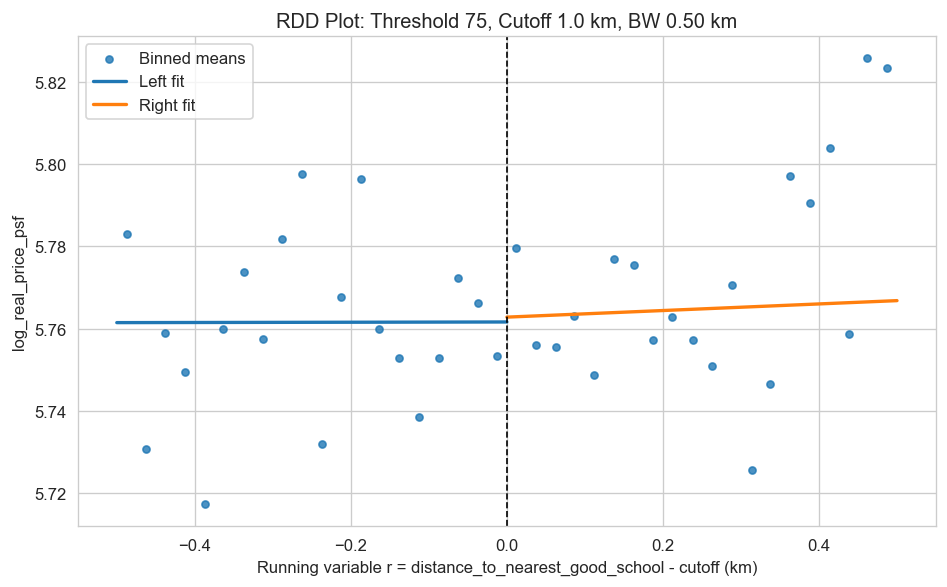

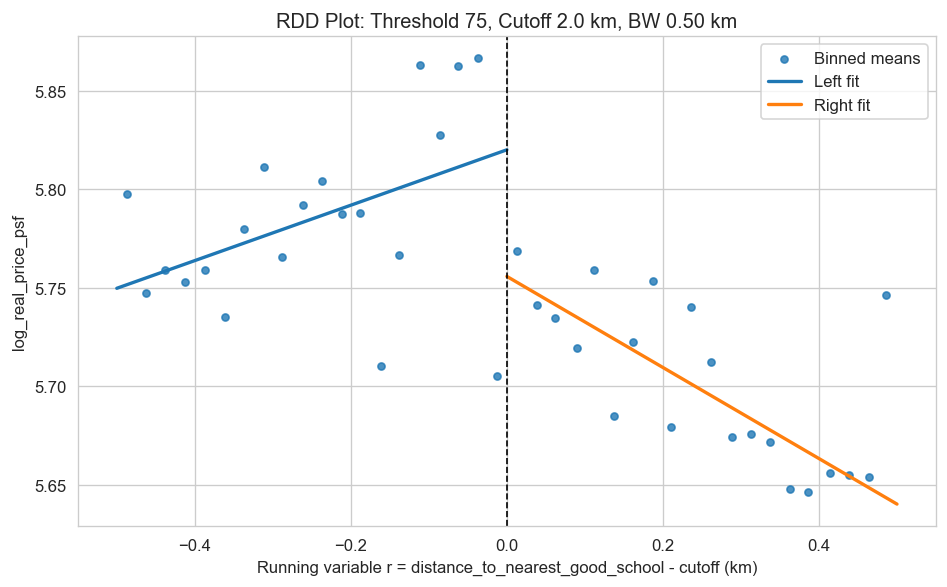

Saved summary: ..\outputs\rdd\rdd_summary.md
All outputs saved to: C:\Users\Keagan\Documents\DSA4264-Public-Policy-and-Society\outputs\rdd


In [9]:
# ===============================
# HDB Good-School RDD Pipeline
# ===============================

import warnings
from math import erf, sqrt
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

import statsmodels.formula.api as smf

try:
    from rdrobust import rdrobust as _rdrobust
    HAS_RDROBUST = True
except Exception:
    HAS_RDROBUST = False

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 180)

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["figure.dpi"] = 120

print(f"rdrobust available: {HAS_RDROBUST}")

# -------------------------------
# Config + data load
# -------------------------------
DATA_DIR = Path("../data")
OUT_DIR = Path("../outputs/rdd")
OUT_DIR.mkdir(parents=True, exist_ok=True)

CANDIDATE_FILES = [
    "hdb_nnearest_sch.csv",  # typo-safe fallback
    "hdb_nearest_sch.csv",
    "final_df.csv",
]

data_path = None
for fname in CANDIDATE_FILES:
    p = DATA_DIR / fname
    if p.exists():
        data_path = p
        break

if data_path is None:
    raise FileNotFoundError(f"None found in {DATA_DIR}: {CANDIDATE_FILES}")

df = pd.read_csv(data_path)
print(f"Loaded: {data_path}")
print(f"Shape: {df.shape}")

OUTCOME = "log_real_price_psf"
THRESHOLDS = [75, 80, 85, 90]
CUTOFFS = [1.0, 2.0]

MAIN_BW = 0.5
BW_GRID = [0.3, 0.5, 0.8, 1.0]
DONUT_GRID = [0.05, 0.10]
PLACEBO_CUTOFFS = [0.8, 1.2]
RING_LOWER_2KM = 1.05

def dist_col(threshold):
    return f"dist_nearest_goodschool_{threshold}"

required_cols = [OUTCOME] + [dist_col(t) for t in THRESHOLDS]
missing = [c for c in required_cols if c not in df.columns]
if missing:
    raise ValueError(
        f"Missing required columns: {missing}\n"
        "Run nearest-school distance engineering first and use hdb_nearest_sch.csv."
    )

if "month" in df.columns:
    df["month"] = pd.to_datetime(df["month"], errors="coerce")
if "year" not in df.columns and "month" in df.columns:
    df["year"] = df["month"].dt.year

for c in required_cols:
    df[c] = pd.to_numeric(df[c], errors="coerce")

df = df.replace([np.inf, -np.inf], np.nan)

print("Missingness in key columns:")
print(df[required_cols].isna().mean().sort_values(ascending=False))

adjusted_terms = []
for col in [
    "floor_area_sqm",
    "remaining_lease_years",
    "dist_to_nearest_mrt_km",
    "dist_to_nearest_mall_km",
    "dist_to_nearest_hawker_km",
    "dist_to_nearest_busstop_km",
    "countall_0_1km",
    "countall_1_2km",
    "mature_estate",
]:
    if col in df.columns:
        adjusted_terms.append(col)
if "year" in df.columns:
    adjusted_terms.append("C(year)")
if "town" in df.columns:
    adjusted_terms.append("C(town)")
ADJUSTED_FORMULA = " + ".join(adjusted_terms) if adjusted_terms else None

print("Adjusted formula extras:", ADJUSTED_FORMULA)

# -------------------------------
# Core RDD helpers
# -------------------------------
def make_running_data(data, threshold, cutoff_km):
    dcol = dist_col(threshold)
    work = data.copy()
    work = work.rename(columns={dcol: "dist"})
    work = work[np.isfinite(work["dist"]) & np.isfinite(work[OUTCOME])].copy()
    work["r"] = work["dist"] - cutoff_km
    work["abs_r"] = work["r"].abs()
    work["treat"] = (work["r"] <= 0).astype(int)
    return work

def kernel_weights(r, bw, kernel="triangular"):
    u = np.abs(r / bw)
    if kernel == "triangular":
        return np.clip(1 - u, 0, None)
    if kernel == "uniform":
        return (u <= 1).astype(float)
    raise ValueError("kernel must be triangular or uniform")

def fit_local_rdd(rdd_df, outcome, bw, poly_order=1, extra_formula=None, kernel="triangular", cov_type="HC1"):
    work = rdd_df.loc[rdd_df["abs_r"] <= bw].copy()
    if work.empty:
        return dict(coef=np.nan, se=np.nan, p_value=np.nan, ci_lo=np.nan, ci_hi=np.nan, n=0, n_left=0, n_right=0)

    work["w"] = kernel_weights(work["r"], bw=bw, kernel=kernel)
    work = work.loc[work["w"] > 0].copy()

    if poly_order == 1:
        rhs = "treat + r + treat:r"
    elif poly_order == 2:
        work["r2"] = work["r"] ** 2
        rhs = "treat + r + treat:r + r2 + treat:r2"
    else:
        raise ValueError("poly_order must be 1 or 2")

    if extra_formula:
        rhs += " + " + extra_formula

    formula = f"{outcome} ~ {rhs}"

    try:
        model = smf.wls(formula=formula, data=work, weights=work["w"]).fit(cov_type=cov_type)
        coef = float(model.params.get("treat", np.nan))
        se = float(model.bse.get("treat", np.nan))
        p = float(model.pvalues.get("treat", np.nan))
        ci_lo = coef - 1.96 * se if np.isfinite(se) else np.nan
        ci_hi = coef + 1.96 * se if np.isfinite(se) else np.nan
    except Exception:
        coef = se = p = ci_lo = ci_hi = np.nan

    return dict(
        coef=coef, se=se, p_value=p, ci_lo=ci_lo, ci_hi=ci_hi,
        n=int(len(work)), n_left=int((work["r"] < 0).sum()), n_right=int((work["r"] >= 0).sum())
    )

def run_rdd_spec(
    data, threshold, cutoff, outcome=OUTCOME, bw=MAIN_BW, poly_order=1,
    extra_formula=None, kernel="triangular", donut_km=0.0, ring_lower_km=None, spec_name="main"
):
    work = make_running_data(data, threshold=threshold, cutoff_km=cutoff)

    if donut_km > 0:
        work = work.loc[work["abs_r"] >= donut_km].copy()
    if ring_lower_km is not None:
        work = work.loc[work["dist"] >= ring_lower_km].copy()

    est = fit_local_rdd(
        rdd_df=work,
        outcome=outcome,
        bw=bw,
        poly_order=poly_order,
        extra_formula=extra_formula,
        kernel=kernel,
        cov_type="HC1",
    )

    est.update({
        "spec": spec_name,
        "outcome": outcome,
        "threshold": threshold,
        "cutoff_km": cutoff,
        "bandwidth_km": bw,
        "kernel": kernel,
        "poly_order": poly_order,
        "donut_km": donut_km,
        "ring_lower_km": ring_lower_km,
        "extra_formula": extra_formula,
        "pct_effect": (np.exp(est["coef"]) - 1) * 100 if np.isfinite(est["coef"]) else np.nan,
    })
    return est

def try_rdrobust(data, threshold, cutoff, outcome=OUTCOME):
    if not HAS_RDROBUST:
        return None
    dcol = dist_col(threshold)
    tmp = data[[outcome, dcol]].dropna().copy()
    tmp = tmp[np.isfinite(tmp[outcome]) & np.isfinite(tmp[dcol])]
    if tmp.empty:
        return None
    try:
        rr = _rdrobust(y=tmp[outcome].values, x=tmp[dcol].values, c=cutoff, p=1)
        tau = np.nan
        se = np.nan
        if hasattr(rr, "coef"):
            arr = np.asarray(rr.coef).reshape(-1)
            if arr.size > 0:
                tau = float(arr[0])
        if hasattr(rr, "se"):
            arr = np.asarray(rr.se).reshape(-1)
            if arr.size > 0:
                se = float(arr[0])
        return {
            "threshold": threshold,
            "cutoff_km": cutoff,
            "rdrobust_tau": tau,
            "rdrobust_se": se,
            "rdrobust_pct": (np.exp(tau) - 1) * 100 if np.isfinite(tau) else np.nan,
        }
    except Exception:
        return None

def plot_rdd_binned(data, threshold, cutoff, bw, outcome=OUTCOME, bins=40, save_path=None):
    work = make_running_data(data, threshold=threshold, cutoff_km=cutoff)
    work = work.loc[work["abs_r"] <= bw].copy()
    if work.empty:
        return

    edges = np.linspace(-bw, bw, bins + 1)
    work["bin"] = pd.cut(work["r"], bins=edges, include_lowest=True)

    binned = (
        work.groupby("bin", observed=False)
        .agg(r_mean=("r", "mean"), y_mean=(outcome, "mean"), n=(outcome, "size"))
        .dropna()
        .reset_index(drop=True)
    )

    left = work[work["r"] < 0].copy()
    right = work[work["r"] >= 0].copy()

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.scatter(binned["r_mean"], binned["y_mean"], s=18, alpha=0.8, label="Binned means")

    if len(left) > 10:
        left["w"] = kernel_weights(left["r"], bw=bw, kernel="triangular")
        m_left = smf.wls(f"{outcome} ~ r", data=left, weights=left["w"]).fit()
        grid_l = np.linspace(-bw, 0, 100)
        pred_l = m_left.predict(pd.DataFrame({"r": grid_l}))
        ax.plot(grid_l, pred_l, linewidth=2, label="Left fit")

    if len(right) > 10:
        right["w"] = kernel_weights(right["r"], bw=bw, kernel="triangular")
        m_right = smf.wls(f"{outcome} ~ r", data=right, weights=right["w"]).fit()
        grid_r = np.linspace(0, bw, 100)
        pred_r = m_right.predict(pd.DataFrame({"r": grid_r}))
        ax.plot(grid_r, pred_r, linewidth=2, label="Right fit")

    ax.axvline(0, color="black", linestyle="--", linewidth=1)
    ax.set_title(f"RDD Plot: Threshold {threshold}, Cutoff {cutoff:.1f} km, BW {bw:.2f} km")
    ax.set_xlabel("Running variable r = distance_to_nearest_good_school - cutoff (km)")
    ax.set_ylabel(outcome)
    ax.legend()
    plt.tight_layout()

    if save_path is not None:
        fig.savefig(save_path, bbox_inches="tight")
    plt.show()

def simple_density_proxy(data, threshold, cutoff, window=0.05):
    tmp = make_running_data(data, threshold=threshold, cutoff_km=cutoff)
    left_n = int(((tmp["r"] >= -window) & (tmp["r"] < 0)).sum())
    right_n = int(((tmp["r"] >= 0) & (tmp["r"] <= window)).sum())

    total = left_n + right_n
    if total == 0:
        z = np.nan
        p = np.nan
    else:
        z = (left_n - right_n) / np.sqrt(total)
        p = 2 * (1 - 0.5 * (1 + erf(abs(z) / sqrt(2))))

    return {
        "threshold": threshold,
        "cutoff_km": cutoff,
        "window_km": window,
        "left_count": left_n,
        "right_count": right_n,
        "z_stat": z,
        "p_value": p,
    }

# -------------------------------
# 1) Main + adjusted specs
# -------------------------------
main_rows = []
for cutoff in CUTOFFS:
    ring_lower = RING_LOWER_2KM if cutoff == 2.0 else None

    main_rows.append(run_rdd_spec(
        data=df, threshold=75, cutoff=cutoff, bw=MAIN_BW, poly_order=1,
        extra_formula=None, donut_km=0.0, ring_lower_km=ring_lower, spec_name="main_minimal"
    ))
    main_rows.append(run_rdd_spec(
        data=df, threshold=75, cutoff=cutoff, bw=MAIN_BW, poly_order=1,
        extra_formula=ADJUSTED_FORMULA, donut_km=0.0, ring_lower_km=ring_lower, spec_name="main_adjusted"
    ))

main_results = pd.DataFrame(main_rows)
main_results.to_csv(OUT_DIR / "rdd_main_results.csv", index=False)

print("Main RDD results:")
display(main_results[[
    "spec", "threshold", "cutoff_km", "bandwidth_km",
    "coef", "se", "p_value", "ci_lo", "ci_hi", "pct_effect", "n", "n_left", "n_right"
]].sort_values(["cutoff_km", "spec"]))

# -------------------------------
# 2) Threshold robustness
# -------------------------------
th_rows = []
for cutoff in CUTOFFS:
    ring_lower = RING_LOWER_2KM if cutoff == 2.0 else None
    for th in THRESHOLDS:
        th_rows.append(run_rdd_spec(
            data=df, threshold=th, cutoff=cutoff, bw=MAIN_BW, poly_order=1,
            extra_formula=None, donut_km=0.0, ring_lower_km=ring_lower, spec_name=f"threshold_{th}"
        ))

threshold_results = pd.DataFrame(th_rows)
threshold_results.to_csv(OUT_DIR / "rdd_threshold_results.csv", index=False)

print("Threshold robustness:")
display(threshold_results[[
    "threshold", "cutoff_km", "coef", "se", "p_value", "pct_effect", "n", "n_left", "n_right"
]].sort_values(["cutoff_km", "threshold"]))

# -------------------------------
# 3) Bandwidth / donut / placebo
# -------------------------------
bw_rows = []
for cutoff in CUTOFFS:
    ring_lower = RING_LOWER_2KM if cutoff == 2.0 else None
    for bw in BW_GRID:
        bw_rows.append(run_rdd_spec(
            data=df, threshold=75, cutoff=cutoff, bw=bw, poly_order=1,
            extra_formula=None, donut_km=0.0, ring_lower_km=ring_lower, spec_name=f"bw_{bw}"
        ))
bw_results = pd.DataFrame(bw_rows)
bw_results.to_csv(OUT_DIR / "rdd_bandwidth_sensitivity.csv", index=False)

donut_rows = []
for d in DONUT_GRID:
    donut_rows.append(run_rdd_spec(
        data=df, threshold=75, cutoff=1.0, bw=MAIN_BW, poly_order=1,
        extra_formula=None, donut_km=d, ring_lower_km=None, spec_name=f"donut_{d}"
    ))
donut_results = pd.DataFrame(donut_rows)
donut_results.to_csv(OUT_DIR / "rdd_donut_results.csv", index=False)

placebo_rows = []
for fake_cutoff in PLACEBO_CUTOFFS:
    placebo_rows.append(run_rdd_spec(
        data=df, threshold=75, cutoff=fake_cutoff, bw=MAIN_BW, poly_order=1,
        extra_formula=None, donut_km=0.0, ring_lower_km=None, spec_name=f"placebo_{fake_cutoff}"
    ))
placebo_results = pd.DataFrame(placebo_rows)
placebo_results.to_csv(OUT_DIR / "rdd_placebo_results.csv", index=False)

print("Bandwidth sensitivity:")
display(bw_results[["cutoff_km", "bandwidth_km", "coef", "se", "p_value", "pct_effect", "n"]]
        .sort_values(["cutoff_km", "bandwidth_km"]))

print("Donut RDD (1km):")
display(donut_results[["spec", "coef", "se", "p_value", "pct_effect", "n"]])

print("Placebo cutoffs:")
display(placebo_results[["cutoff_km", "coef", "se", "p_value", "pct_effect", "n"]].sort_values("cutoff_km"))

# -------------------------------
# 4) Covariate continuity + density proxy
# -------------------------------
balance_covariates = [
    "floor_area_sqm",
    "remaining_lease_years",
    "dist_to_nearest_mrt_km",
    "dist_to_nearest_mall_km",
    "dist_to_nearest_hawker_km",
    "dist_to_nearest_busstop_km",
    "countall_0_1km",
    "countall_1_2km",
]
balance_covariates = [c for c in balance_covariates if c in df.columns]

balance_rows = []
for cov in balance_covariates:
    balance_rows.append(run_rdd_spec(
        data=df, threshold=75, cutoff=1.0, outcome=cov, bw=MAIN_BW, poly_order=1,
        extra_formula=None, donut_km=0.0, ring_lower_km=None, spec_name=f"balance_{cov}"
    ))
balance_results = pd.DataFrame(balance_rows)
balance_results.to_csv(OUT_DIR / "rdd_covariate_balance.csv", index=False)

density_rows = []
for cutoff in [1.0, 2.0]:
    density_rows.append(simple_density_proxy(df, threshold=75, cutoff=cutoff, window=0.05))
    density_rows.append(simple_density_proxy(df, threshold=75, cutoff=cutoff, window=0.10))
density_results = pd.DataFrame(density_rows)
density_results.to_csv(OUT_DIR / "rdd_density_proxy.csv", index=False)

print("Covariate continuity at 1km:")
display(balance_results[["outcome", "coef", "se", "p_value", "n"]].sort_values("p_value"))

print("Density proxy:")
display(density_results.sort_values(["cutoff_km", "window_km"]))

# -------------------------------
# 5) Optional rdrobust cross-check
# -------------------------------
rdrobust_rows = []
for cutoff in CUTOFFS:
    out = try_rdrobust(df, threshold=75, cutoff=cutoff, outcome=OUTCOME)
    if out is not None:
        rdrobust_rows.append(out)

if rdrobust_rows:
    rdrobust_results = pd.DataFrame(rdrobust_rows)
    rdrobust_results.to_csv(OUT_DIR / "rdd_rdrobust_crosscheck.csv", index=False)
    print("rdrobust cross-check:")
    display(rdrobust_results)
else:
    print("rdrobust not available or failed; skipping cross-check.")

# -------------------------------
# 6) Plots + summary markdown
# -------------------------------
plot_rdd_binned(
    data=df, threshold=75, cutoff=1.0, bw=MAIN_BW, outcome=OUTCOME, bins=40,
    save_path=OUT_DIR / "rdd_plot_threshold75_cutoff1km.png",
)
plot_rdd_binned(
    data=df, threshold=75, cutoff=2.0, bw=MAIN_BW, outcome=OUTCOME, bins=40,
    save_path=OUT_DIR / "rdd_plot_threshold75_cutoff2km.png",
)

summary_lines = []
summary_lines.append("# RDD Summary")
summary_lines.append("")
summary_lines.append(f"Data source: {data_path}")
summary_lines.append(f"Outcome: {OUTCOME}")
summary_lines.append(f"Main bandwidth: {MAIN_BW} km")
summary_lines.append("")
summary_lines.append("## Main specs (threshold=75)")

for _, row in main_results.sort_values(["cutoff_km", "spec"]).iterrows():
    summary_lines.append(
        f"- {row['spec']} | cutoff={row['cutoff_km']:.1f} km | "
        f"coef={row['coef']:.4f} | se={row['se']:.4f} | p={row['p_value']:.4g} | "
        f"pct={row['pct_effect']:.2f}% | n={int(row['n'])}"
    )

summary_lines.append("")
summary_lines.append("## Files generated")
for p in sorted(OUT_DIR.glob("*")):
    summary_lines.append(f"- {p.name}")

summary_path = OUT_DIR / "rdd_summary.md"
summary_path.write_text("\n".join(summary_lines), encoding="utf-8")

print(f"Saved summary: {summary_path}")
print("All outputs saved to:", OUT_DIR.resolve())


## Improved RDD

In [10]:
# ===============================
# Improved RDD: School FE + Clustered SE
# ===============================

OUT_DIR_IMP = Path("../outputs/rdd_improved")
OUT_DIR_IMP.mkdir(parents=True, exist_ok=True)

IMP_MAIN_BW = 0.5
IMP_BW_GRID = [0.3, 0.5, 0.8, 1.0]
IMP_DONUT_GRID = [0.05, 0.10]
IMP_THRESHOLDS = [75, 80, 85, 90]
IMP_CUTOFFS = [1.0, 2.0]
IMP_RING_LOWER_2KM = 1.05

IMP_CONTROLS = [
    "floor_area_sqm",
    "remaining_lease_years",
    "mature_estate",
    "dist_to_nearest_mrt_km",
    "dist_to_nearest_mall_km",
    "dist_to_nearest_hawker_km",
    "dist_to_nearest_busstop_km",
    "countall_0_1km",
    "countall_1_2km",
]

def school_col(threshold):
    return f"sch_name_{threshold}"

def run_schoolfe_rdd_spec(
    data,
    threshold,
    cutoff,
    outcome=OUTCOME,
    bw=IMP_MAIN_BW,
    kernel="triangular",
    donut_km=0.0,
    ring_lower_km=None,
    include_controls=False,
    add_year_fe=True,
    spec_name="schoolfe",
):
    s_col = school_col(threshold)
    if s_col not in data.columns:
        raise ValueError(f"Missing school-name column: {s_col}")

    work = make_running_data(data, threshold=threshold, cutoff_km=cutoff).copy()
    work["school_id"] = work[s_col].astype("string")

    work = work[work["school_id"].notna()].copy()
    if donut_km > 0:
        work = work.loc[work["abs_r"] >= donut_km].copy()
    if ring_lower_km is not None:
        work = work.loc[work["dist"] >= ring_lower_km].copy()

    work = work.loc[work["abs_r"] <= bw].copy()
    work["w"] = kernel_weights(work["r"], bw=bw, kernel=kernel)
    work = work.loc[work["w"] > 0].copy()

    rhs = ["treat", "r", "treat:r", "C(school_id)"]
    if add_year_fe and ("year" in work.columns):
        rhs.append("C(year)")
    if include_controls:
        rhs.extend([c for c in IMP_CONTROLS if c in work.columns])

    needed = ["treat", "r", outcome, "school_id", "w"]
    needed += [c for c in IMP_CONTROLS if include_controls and c in work.columns]
    if add_year_fe and ("year" in work.columns):
        needed.append("year")
    work = work.dropna(subset=list(dict.fromkeys(needed))).copy()

    if len(work) == 0:
        return {
            "coef": np.nan, "se": np.nan, "p_value": np.nan, "ci_lo": np.nan, "ci_hi": np.nan,
            "n": 0, "n_left": 0, "n_right": 0, "n_clusters": 0,
            "spec": spec_name, "outcome": outcome, "threshold": threshold, "cutoff_km": cutoff,
            "bandwidth_km": bw, "donut_km": donut_km, "ring_lower_km": ring_lower_km,
            "include_controls": include_controls, "add_year_fe": add_year_fe,
            "pct_effect": np.nan,
        }

    formula = f"{outcome} ~ " + " + ".join(rhs)
    n_clusters = int(work["school_id"].nunique())

    try:
        base_model = smf.wls(formula=formula, data=work, weights=work["w"])
        if n_clusters >= 2:
            model = base_model.fit(cov_type="cluster", cov_kwds={"groups": work["school_id"]})
        else:
            model = base_model.fit(cov_type="HC1")

        coef = float(model.params.get("treat", np.nan))
        se = float(model.bse.get("treat", np.nan))
        p = float(model.pvalues.get("treat", np.nan))
        ci_lo = coef - 1.96 * se if np.isfinite(se) else np.nan
        ci_hi = coef + 1.96 * se if np.isfinite(se) else np.nan
    except Exception:
        coef = se = p = ci_lo = ci_hi = np.nan

    pct_effect = (np.exp(coef) - 1) * 100 if (outcome == OUTCOME and np.isfinite(coef)) else np.nan

    return {
        "coef": coef,
        "se": se,
        "p_value": p,
        "ci_lo": ci_lo,
        "ci_hi": ci_hi,
        "n": int(len(work)),
        "n_left": int((work["r"] < 0).sum()),
        "n_right": int((work["r"] >= 0).sum()),
        "n_clusters": n_clusters,
        "spec": spec_name,
        "outcome": outcome,
        "threshold": threshold,
        "cutoff_km": cutoff,
        "bandwidth_km": bw,
        "donut_km": donut_km,
        "ring_lower_km": ring_lower_km,
        "include_controls": include_controls,
        "add_year_fe": add_year_fe,
        "pct_effect": pct_effect,
    }


# 1) Main improved specs (threshold=75)
imp_main_rows = []
for cutoff in IMP_CUTOFFS:
    ring_lower = IMP_RING_LOWER_2KM if cutoff == 2.0 else None
    imp_main_rows.append(
        run_schoolfe_rdd_spec(
            data=df, threshold=75, cutoff=cutoff, outcome=OUTCOME, bw=IMP_MAIN_BW,
            donut_km=0.0, ring_lower_km=ring_lower, include_controls=False, add_year_fe=True,
            spec_name="schoolfe_minimal"
        )
    )
    imp_main_rows.append(
        run_schoolfe_rdd_spec(
            data=df, threshold=75, cutoff=cutoff, outcome=OUTCOME, bw=IMP_MAIN_BW,
            donut_km=0.0, ring_lower_km=ring_lower, include_controls=True, add_year_fe=True,
            spec_name="schoolfe_adjusted"
        )
    )

imp_main = pd.DataFrame(imp_main_rows)
imp_main.to_csv(OUT_DIR_IMP / "rdd_schoolfe_main_results.csv", index=False)

print("Improved main RDD (school FE + clustered SE):")
display(imp_main.sort_values(["cutoff_km", "spec"]))


# 2) Threshold robustness (school FE)
imp_th_rows = []
for cutoff in IMP_CUTOFFS:
    ring_lower = IMP_RING_LOWER_2KM if cutoff == 2.0 else None
    for th in IMP_THRESHOLDS:
        imp_th_rows.append(
            run_schoolfe_rdd_spec(
                data=df, threshold=th, cutoff=cutoff, outcome=OUTCOME, bw=IMP_MAIN_BW,
                donut_km=0.0, ring_lower_km=ring_lower, include_controls=False, add_year_fe=True,
                spec_name=f"schoolfe_threshold_{th}"
            )
        )

imp_threshold = pd.DataFrame(imp_th_rows)
imp_threshold.to_csv(OUT_DIR_IMP / "rdd_schoolfe_threshold_results.csv", index=False)

print("Improved threshold robustness:")
display(imp_threshold.sort_values(["cutoff_km", "threshold"]))


# 3) Bandwidth sensitivity (school FE)
imp_bw_rows = []
for cutoff in IMP_CUTOFFS:
    ring_lower = IMP_RING_LOWER_2KM if cutoff == 2.0 else None
    for bw in IMP_BW_GRID:
        imp_bw_rows.append(
            run_schoolfe_rdd_spec(
                data=df, threshold=75, cutoff=cutoff, outcome=OUTCOME, bw=bw,
                donut_km=0.0, ring_lower_km=ring_lower, include_controls=False, add_year_fe=True,
                spec_name=f"schoolfe_bw_{bw}"
            )
        )

imp_bw = pd.DataFrame(imp_bw_rows)
imp_bw.to_csv(OUT_DIR_IMP / "rdd_schoolfe_bandwidth_sensitivity.csv", index=False)

print("Improved bandwidth sensitivity:")
display(imp_bw.sort_values(["cutoff_km", "bandwidth_km"]))


# 4) Donut checks (school FE, 1km cutoff)
imp_donut_rows = []
for d in IMP_DONUT_GRID:
    imp_donut_rows.append(
        run_schoolfe_rdd_spec(
            data=df, threshold=75, cutoff=1.0, outcome=OUTCOME, bw=IMP_MAIN_BW,
            donut_km=d, ring_lower_km=None, include_controls=False, add_year_fe=True,
            spec_name=f"schoolfe_donut_{d}"
        )
    )

imp_donut = pd.DataFrame(imp_donut_rows)
imp_donut.to_csv(OUT_DIR_IMP / "rdd_schoolfe_donut_results.csv", index=False)

print("Improved donut checks:")
display(imp_donut)


# 5) Covariate continuity under school FE structure (1km, threshold=75)
imp_balance_covs = [c for c in IMP_CONTROLS if c in df.columns]
imp_balance_rows = []
for cov in imp_balance_covs:
    imp_balance_rows.append(
        run_schoolfe_rdd_spec(
            data=df, threshold=75, cutoff=1.0, outcome=cov, bw=IMP_MAIN_BW,
            donut_km=0.0, ring_lower_km=None, include_controls=False, add_year_fe=True,
            spec_name=f"schoolfe_balance_{cov}"
        )
    )

imp_balance = pd.DataFrame(imp_balance_rows)
imp_balance.to_csv(OUT_DIR_IMP / "rdd_schoolfe_covariate_balance.csv", index=False)

print("Improved covariate balance:")
display(imp_balance.sort_values("p_value"))


# 6) Summary markdown
imp_summary_lines = []
imp_summary_lines.append("# Improved RDD Summary (School FE + Clustered SE)")
imp_summary_lines.append("")
imp_summary_lines.append(f"Data source: {data_path}")
imp_summary_lines.append(f"Outcome: {OUTCOME}")
imp_summary_lines.append(f"Main bandwidth: {IMP_MAIN_BW} km")
imp_summary_lines.append("")
imp_summary_lines.append("## Main specs (threshold=75)")

for _, row in imp_main.sort_values(["cutoff_km", "spec"]).iterrows():
    imp_summary_lines.append(
        f"- {row['spec']} | cutoff={row['cutoff_km']:.1f} km | "
        f"coef={row['coef']:.4f} | se={row['se']:.4f} | p={row['p_value']:.4g} | "
        f"pct={row['pct_effect']:.2f}% | n={int(row['n'])} | clusters={int(row['n_clusters'])}"
    )

imp_summary_lines.append("")
imp_summary_lines.append("## Files generated")
for p in sorted(OUT_DIR_IMP.glob("*")):
    imp_summary_lines.append(f"- {p.name}")

imp_summary_path = OUT_DIR_IMP / "rdd_schoolfe_summary.md"
imp_summary_path.write_text("\n".join(imp_summary_lines), encoding="utf-8")

print(f"Saved improved summary: {imp_summary_path}")
print("All improved outputs saved to:", OUT_DIR_IMP.resolve())


Improved main RDD (school FE + clustered SE):


,coef,se,p_value,ci_lo,ci_hi,n,n_left,n_right,n_clusters,spec,outcome,threshold,cutoff_km,bandwidth_km,donut_km,ring_lower_km,include_controls,add_year_fe,pct_effect
1,-0.005354,0.005474,0.327986,-0.016083,0.005374,156398,96435,59963,63,schoolfe_adjusted,log_real_price_psf,75,1.0,0.5,0.0,NaN,True,True,-0.533994
0,-0.007712,0.012409,0.534293,-0.032032,0.016609,156398,96435,59963,63,schoolfe_minimal,log_real_price_psf,75,1.0,0.5,0.0,NaN,False,True,-0.768187
3,0.001746,0.009004,0.846206,-0.015901,0.019394,56378,38404,17974,51,schoolfe_adjusted,log_real_price_psf,75,2.0,0.5,0.0,1.05,True,True,0.174788
2,0.055052,0.041718,0.186960,-0.026715,0.136820,56378,38404,17974,51,schoolfe_minimal,log_real_price_psf,75,2.0,0.5,0.0,1.05,False,True,5.659599


Improved threshold robustness:


,coef,se,p_value,ci_lo,ci_hi,n,n_left,n_right,n_clusters,spec,outcome,threshold,cutoff_km,bandwidth_km,donut_km,ring_lower_km,include_controls,add_year_fe,pct_effect
0,-0.007712,0.012409,0.534293,-0.032032,0.016609,156398,96435,59963,63,schoolfe_threshold_75,log_real_price_psf,75,1.0,0.5,0.0,NaN,False,True,-0.768187
1,-0.017057,0.011120,0.125072,-0.038852,0.004739,134487,76008,58479,53,schoolfe_threshold_80,log_real_price_psf,80,1.0,0.5,0.0,NaN,False,True,-1.691192
2,-0.015159,0.010163,0.135802,-0.035078,0.004760,115879,60454,55425,42,schoolfe_threshold_85,log_real_price_psf,85,1.0,0.5,0.0,NaN,False,True,-1.504466
3,-0.005510,0.016689,0.741267,-0.038221,0.027201,82052,40007,42045,32,schoolfe_threshold_90,log_real_price_psf,90,1.0,0.5,0.0,NaN,False,True,-0.549525
4,0.055052,0.041718,0.186960,-0.026715,0.136820,56378,38404,17974,51,schoolfe_threshold_75,log_real_price_psf,75,2.0,0.5,0.0,1.05,False,True,5.659599
5,0.005988,0.012836,0.640862,-0.019171,0.031147,69786,41466,28320,45,schoolfe_threshold_80,log_real_price_psf,80,2.0,0.5,0.0,1.05,False,True,0.600603
6,0.007627,0.013652,0.576387,-0.019131,0.034384,74720,43270,31450,39,schoolfe_threshold_85,log_real_price_psf,85,2.0,0.5,0.0,1.05,False,True,0.765603
7,0.008982,0.017492,0.607594,-0.025302,0.043267,73953,39637,34316,29,schoolfe_threshold_90,log_real_price_psf,90,2.0,0.5,0.0,1.05,False,True,0.902290


Improved bandwidth sensitivity:


...

Improved donut checks:


,coef,se,p_value,ci_lo,ci_hi,n,n_left,n_right,n_clusters,spec,outcome,threshold,cutoff_km,bandwidth_km,donut_km,ring_lower_km,include_controls,add_year_fe,pct_effect
0,-0.008370,0.019453,0.667004,-0.046497,0.029758,140031,88136,51895,63,schoolfe_donut_0.05,log_real_price_psf,75,1.0,0.5,0.05,None,False,True,-0.833487
1,-0.011387,0.023206,0.623660,-0.056871,0.034098,124614,79537,45077,63,schoolfe_donut_0.1,log_real_price_psf,75,1.0,0.5,0.10,None,False,True,-1.132213


Improved covariate balance:


,coef,se,p_value,ci_lo,ci_hi,n,n_left,n_right,n_clusters,spec,outcome,threshold,cutoff_km,bandwidth_km,donut_km,ring_lower_km,include_controls,add_year_fe,pct_effect
7,1.032944,0.066956,1.072677e-53,0.901711,1.164177,156398,96435,59963,63,schoolfe_balance_countall_0_1km,countall_0_1km,75,1.0,0.5,0.0,None,False,True,NaN
8,-1.021518,0.116668,2.026967e-18,-1.250186,-0.792849,156398,96435,59963,63,schoolfe_balance_countall_1_2km,countall_1_2km,75,1.0,0.5,0.0,None,False,True,NaN
3,0.026955,0.018753,1.506253e-01,-0.009802,0.063711,156398,96435,59963,63,schoolfe_balance_dist_to_nearest_mrt_km,dist_to_nearest_mrt_km,75,1.0,0.5,0.0,None,False,True,NaN
5,-0.024238,0.017091,1.561543e-01,-0.057737,0.009261,156398,96435,59963,63,schoolfe_balance_dist_to_nearest_hawker_km,dist_to_nearest_hawker_km,75,1.0,0.5,0.0,None,False,True,NaN
6,0.005201,0.004123,2.070676e-01,-0.002879,0.013282,156398,96435,59963,63,schoolfe_balance_dist_to_nearest_busstop_km,dist_to_nearest_busstop_km,75,1.0,0.5,0.0,None,False,True,NaN
4,-0.015644,0.017913,3.824850e-01,-0.050753,0.019465,156398,96435,59963,63,schoolfe_balance_dist_to_nearest_mall_km,dist_to_nearest_mall_km,75,1.0,0.5,0.0,None,False,True,NaN
0,1.006216,1.252632,4.218121e-01,-1.448943,3.461375,156398,96435,59963,63,schoolfe_balance_floor_area_sqm,floor_area_sqm,75,1.0,0.5,0.0,None,False,True,NaN
1,0.497843,0.926915,5.912008e-01,-1.318910,2.314596,156398,96435,59963,63,schoolfe_balance_remaining_lease_years,remaining_lease_years,75,1.0,0.5,0.0,None,False,True,NaN
2,-0.000755,0.001613,6.397502e-01,-0.003915,0.002406,156398,96435,59963,63,schoolfe_balance_mature_estate,mature_estate,75,1.0,0.5,0.0,None,False,True,NaN


Saved improved summary: ..\outputs\rdd_improved\rdd_schoolfe_summary.md
All improved outputs saved to: C:\Users\Keagan\Documents\DSA4264-Public-Policy-and-Society\outputs\rdd_improved
